# Sophisticated inference on Graph Worlds

This notebook demonstrates tree searching policies with sophisticated active inference.

We create a `GraphEnv`, where an agent can move between locations on a graph, and see objects at the location it is at.

In [1]:
from jax import numpy as jnp, random as jr
from jax import vmap
import jax.tree_util as jtu
from pymdp.utils import list_array_zeros, list_array_norm_dist

In [2]:
import networkx as nx
from pymdp.envs import GraphEnv
from pymdp.envs.graph_worlds import generate_connected_clusters

graph, _ = generate_connected_clusters(cluster_size=3, connections=2)
env = GraphEnv(graph, object_location=4, agent_location=0)

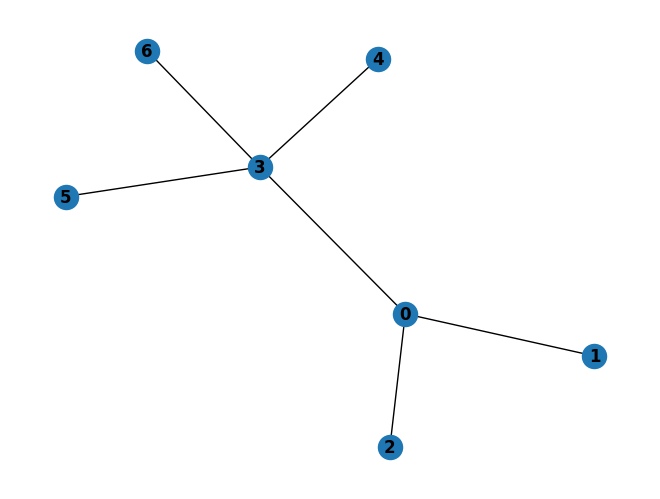

In [3]:
nx.draw(graph, with_labels=True, font_weight="bold")

Let's create an agent, we give the agent a prior on the object location to showcase the planning depth and pruning. We let the agent start at location 0, and give it a prior about where the object is (location 4).

In [4]:
from pymdp.agent import Agent

A, B = env.A, env.B
A_dependencies, B_dependencies = env.A_dependencies, env.B_dependencies

C = list_array_zeros([a.shape[0] for a in A])
C[1] = C[1].at[1].set(10.0)

D = [jnp.ones(d.shape[0]) for d in env.D]
D[0] = D[0].at[0].set(100.0)
D[1] = D[1].at[4].set(100.0)
D = list_array_norm_dist(D)

agent = Agent(A, B, C, D, A_dependencies=A_dependencies, B_dependencies=B_dependencies, policy_len=1)

Now we can call the `si_policy_search` method and visualize the planning tree.

In [5]:
from pymdp.planning.si import si_policy_search
from pymdp.envs import rollout

key = jr.PRNGKey(0)
last, info = rollout(agent, env, 5, key, policy_search=si_policy_search(horizon=3))

Given the agent prior, it should commit to going to location 4, expecting to see the object there.

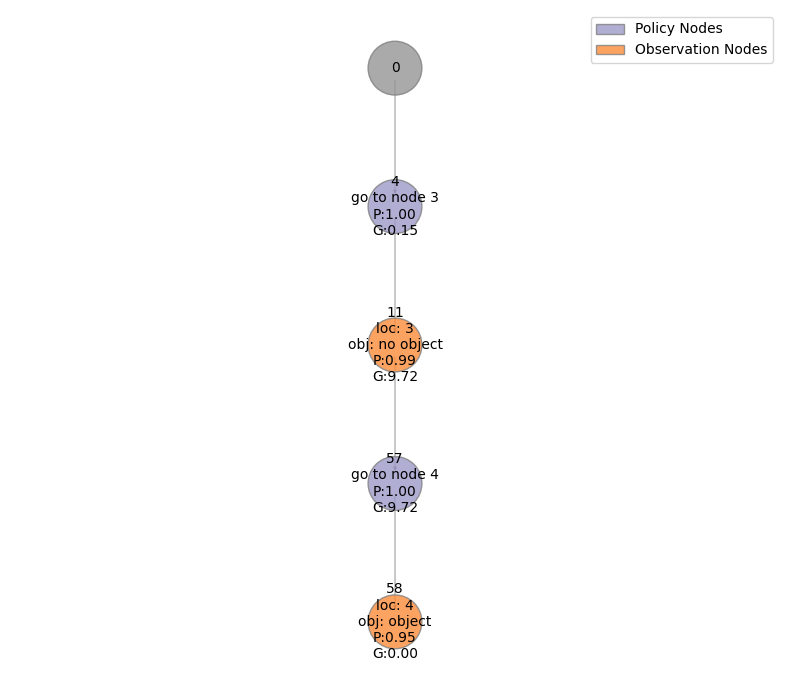

In [6]:
from pymdp.planning.visualize import visualize_plan_tree

def graph_world_observation_description(observation, model=None, graph=graph):
    obs = observation[0]
    loc_idx = int(obs[0])
    obj_val = int(obs[1])

    obj_str = "object" if obj_val == 1 else "no object"
    return f"loc: {loc_idx}\nobj: {obj_str}"


def graph_world_action_description(action, model=None, graph=graph):
    action_idx = int(action[0])
    if action_idx in graph.nodes:
        return f"go to node {action_idx}"
    return str(action_idx)


visualize_plan_tree(
    info,
    observation_description=graph_world_observation_description,
    action_description=graph_world_action_description,
)
